# Generate Figure 2 panels

### Libraries and Analysis-Wide Variables

In [36]:
options(warn = -1)

suppressPackageStartupMessages({
  library(plyranges)
  library(tidyverse)
  library(rasilabRtemplates)
  library(ggpubr)
  library(RColorBrewer)
  library(Biostrings)
  library(cowplot)
})

wildtype_boxb <- "GGGCCCTGAAGAAGGGCCC"
wildtype_boxb_rc <- "GGGCCCTTCTTCAGGGCCC"
time_order=c("37_30min","37_1hr","37_2hr")
position_order=c("5","3")

### Read In Data

In [37]:
target_data <- list.files("../data/summary_stats_combined/", full.names = T, pattern = ".csv.gz") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    print()

# A tibble: 1,391,218 × 89
   sample_id barcode    insert umi_cou…¹ num_0_a num_0_g num_0_t num_0_c num_0_n
   <chr>     <chr>      <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 i79_p1    AAAAGACAGG TTGAG        186     186     186       0     185     186
 2 i79_p1    AAAAGACAGG GTGAT        127     126     127       0     127     127
 3 i79_p1    AAAAGACAGG AGTCA         62      62      62       0      62      62
 4 i79_p1    AAAAGACAGG GAAGT        109     109     109       0     107     109
 5 i79_p1    AAAAGACAGG ATTGA         90      89      90       0      90      90
 6 i79_p1    AAAAGACAGG CAAGC         49      49      49       0      48      49
 7 i79_p1    AAAAGACAGG GATAT         97      97      97       0      94      97
 8 i79_p1    AAAAGACAGG GTATT        144     144     144       0     144     144
 9 i79_p1    AAAAGACAGG TTAAG        104     104     104       0     103     104
10 i79_p1    AAAAGACAGG TGGCA         91      91      91       0      90      91
#

In [38]:
boxb_loop_data <- list.files("../data/boxb_stats_combined/", full.names = T, pattern = ".csv.gz") %>%
    read_csv(show_col_types = F) %>%
    janitor::clean_names() %>%
    print()

# A tibble: 1,391,218 × 39
   sample_id barcode    insert umi_cou…¹ num_0_a num_0_g num_0_t num_0_c num_0_n
   <chr>     <chr>      <chr>      <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 i79_p1    AAAAGACAGG TTGAG        186     186     186       0     186     186
 2 i79_p1    AAAAGACAGG GTGAT        127     127     127       0     127     127
 3 i79_p1    AAAAGACAGG AGTCA         62      62      62       0      62      62
 4 i79_p1    AAAAGACAGG GAAGT        109     109     109       0     109     109
 5 i79_p1    AAAAGACAGG ATTGA         90      90      90       0      90      90
 6 i79_p1    AAAAGACAGG CAAGC         49      49      49       0      49      49
 7 i79_p1    AAAAGACAGG GATAT         97      97      97       0      97      97
 8 i79_p1    AAAAGACAGG GTATT        144     144     144       0     144     144
 9 i79_p1    AAAAGACAGG TTAAG        104     104     104       0     104     104
10 i79_p1    AAAAGACAGG TGGCA         91      91      91       0      91      91
#

### Read in Annotations and Join

In [39]:
barcode_annotations <- read_csv("../annotations/barcode_annotations.csv", show_col_types = F) %>%
    select(-barcode) %>%
    rename(barcode = reverse_complement) %>%
    print()

sample_annotations <- read_csv("../annotations/sample_info.csv", show_col_types = F) %>%
    print()

hairpin_annotations <- read_tsv("../annotations/hairpin_annotations.tsv", show_col_types = F) %>%
    rename("insert" = "variable_region") %>%
    print()

target_data <- target_data %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(sample_annotations, by = "sample_id") %>%
    print()

loop_data <- boxb_loop_data %>%
    left_join(barcode_annotations, by = "barcode") %>%
    left_join(sample_annotations, by = "sample_id") %>%
    print()

# A tibble: 96 × 14
   barcode    oligo_name n_var…¹ varia…² varia…³ targe…⁴ targe…⁵ targe…⁶ targe…⁷
   <chr>      <chr>        <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>
 1 AAGACGCCCA spacer5_3…    1024      62      17      62      17       5      30
 2 CGCGGGACCG spacer3_3…    1024      42      17      42      17       3       0
 3 CGAAAAGAGC spacer5_3…    1024      62      17      62      17       5      30
 4 CCGCACCGCC spacer3_3…    1024      42      17      42      17       3       0
 5 CGAAACAGAA spacer5_2…    1024      60      17      60      17       5      28
 6 GGCGCACAGA spacer3_2…    1024      40      17      40      17       3       2
 7 CAACCAGCCA spacer5_2…    1024      60      17      60      17       5      28
 8 AGAAAGACCA spacer3_2…    1024      40      17      40      17       3       2
 9 AAAAGACAGG spacer5_2…    1024      58      17      58      17       5      26
10 CCACCGAGCC spacer3_2…    1024      38      17      38      17       3       4
# … with

### Create list of wild-type and mutated stems for initial comparisons to TadA alone

In [40]:
boxb_wt_mut_stems <- list(wt = c(
 "1_3" = "CCC",
 "4_6" = "GGG",
 "14_16" = "CCC",
  "17_19" = "GGG"),
  mut = c(
 "1_3" = "GGG",
 "4_6" = "CCC",
 "14_16" = "GGG",
  "17_19" = "CCC")
)  %>% 
  as.data.frame() %>% 
  rownames_to_column("variable_subpos") %>%
  pivot_longer(cols = c("wt", "mut"), names_to = "insert_type", values_to = "insert") %>%
  print()



# A tibble: 8 × 3
  variable_subpos insert_type insert
  <chr>           <chr>       <chr> 
1 1_3             wt          CCC   
2 1_3             mut         GGG   
3 4_6             wt          GGG   
4 4_6             mut         CCC   
5 14_16           wt          CCC   
6 14_16           mut         GGG   
7 17_19           wt          GGG   
8 17_19           mut         CCC   


## TadA Lambda N vs TadA Only, different concentrations, wild-type and mutated boxB stem loops,recorder region

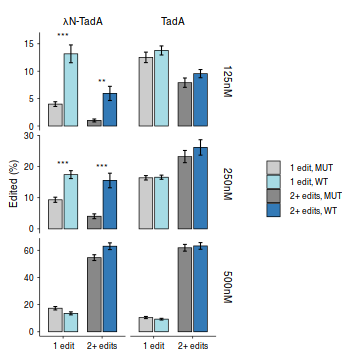

In [41]:
options(repr.plot.width = 3, repr.plot.height = 3)

# Process recorder data
mean_editing_per_concentration <- target_data %>%
  filter(variable_type=="boxb", g_depleted == "no", tada_type %in% c("tada_only", "lambdaN"), condition == "37_2hr") %>%
  inner_join(boxb_wt_mut_stems, by = c("variable_subpos", "insert")) %>%
  mutate(frac_1edit = num_1_c / umi_counts, 
         frac_2edit = (num_2_c + num_3_c + num_4_c + num_5_c + num_6_c + num_7_c) / umi_counts) %>%
  pivot_longer(cols = matches("^frac"), names_to = "edit_type", values_to = "fraction_edited") %>%
  group_by(tada_type, tada_conc, edit_type, insert_type) %>%
  summarize(mean = 100 * mean(fraction_edited), se = 100 * sd(fraction_edited)/sqrt(n()), .groups = "drop")

mean_editing_per_concentration %>% 
  mutate(across(c(mean, se), ~ signif(.x, 3))) %>%
  write_csv("../tables/fig2b_recorder.csv")

# Statistical tests
stat_data <- target_data %>%
  filter(variable_type=="boxb", g_depleted == "no", tada_type %in% c("tada_only", "lambdaN"), condition == "37_2hr") %>%
  inner_join(boxb_wt_mut_stems, by = c("variable_subpos", "insert")) %>%
  mutate(frac_1edit = num_1_c / umi_counts, frac_2edit = (num_2_c + num_3_c + num_4_c) / umi_counts) %>%
  pivot_longer(cols = matches("^frac"), names_to = "edit_type", values_to = "fraction_edited") %>%
  group_by(tada_type, tada_conc, edit_type) %>%
  do(broom::tidy(t.test(fraction_edited ~ insert_type, data = .))) %>%
  ungroup() %>%
  mutate(p_adj = p.adjust(p.value, method = "BH"),
         significance = case_when(p_adj < 0.001 ~ "***", p_adj < 0.01 ~ "**", 
                                 p_adj < 0.05 ~ "*", TRUE ~ "ns")) %>%
  left_join(mean_editing_per_concentration %>% group_by(tada_type, tada_conc, edit_type) %>% 
            summarize(y.position = max(mean + se) * 1.1, .groups = "drop"), 
            by = c("tada_type", "tada_conc", "edit_type")) %>%
  mutate(group1 = "mut", group2 = "wt", label = significance)

# Plot
bar_colors <- c("frac_1edit_mut" = "#cccccc", "frac_1edit_wt" = "#a6dbe5",
                "frac_2edit_mut" = "#888888", "frac_2edit_wt" = "#337ab7")

mean_editing_per_concentration %>%
  ggplot(aes(x = edit_type, y = mean, ymax = mean + se, ymin = mean - se,
            fill = paste(edit_type, insert_type, sep = "_"))) +
  geom_col(color = "black", linewidth = 0.2, position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(width = 0.2, linewidth = 0.3, position = position_dodge(width = 0.8)) +
  facet_grid(tada_conc ~ tada_type, scales = "free_y",
            labeller = labeller(tada_type = c("tada_only" = "TadA", "lambdaN" = "λN-TadA"))) +
  scale_x_discrete(labels = c("frac_1edit" = "1 edit", "frac_2edit" = "2+ edits")) +
  scale_fill_manual(values = bar_colors,
                    labels = c("frac_1edit_mut" = "1 edit, MUT", "frac_1edit_wt" = "1 edit, WT",
                              "frac_2edit_mut" = "2+ edits, MUT", "frac_2edit_wt" = "2+ edits, WT"),
                    name = NULL) +
  labs(x = NULL, y = "Edited (%)") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5, size = 5, color = "black"),
    axis.text.y = element_text(size = 5, color = "black"),
    axis.title = element_text(size = 6, color = "black"),
    legend.text = element_text(size = 5, color = "black"),
    strip.text = element_text(size = 6, color = "black"),
    panel.spacing = unit(0.2, "lines"),
    legend.position = "right",
    legend.key.size = unit(0.3, "cm"),
    axis.line = element_line(linewidth = 0.2, color = "black"),
    axis.ticks = element_line(linewidth = 0.2, color = "black"),
    axis.ticks.length = unit(0.05, "cm"),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "white"),
    plot.background = element_rect(fill = "white"),
    plot.margin = margin(2, 2, 2, 2, "mm")
  ) +
  stat_pvalue_manual(
    data = stat_data %>% filter(significance != "ns"),
    x = "edit_type", y.position = "y.position", 
    tip.length = 0.01, size = 2, inherit.aes = FALSE
  )

ggsave("../figures/fig2b_recorder.pdf", width = 3, height = 3, units = "in", dpi = 600)

## TadA Lambda N vs TadA Only, different concentrations, wild-type and mutated boxB stem loops, loop region

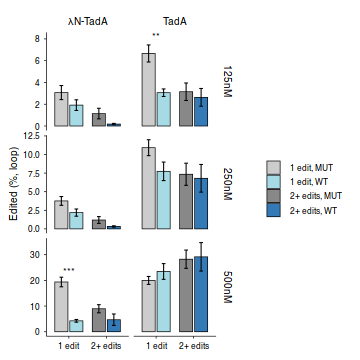

In [42]:
options(repr.plot.width = 3, repr.plot.height = 3)

# Process loop data
mean_loop_editing_per_concentration <- loop_data %>%
  filter(variable_type=="boxb", g_depleted == "no", tada_type %in% c("tada_only", "lambdaN"), condition == "37_2hr") %>%
  inner_join(boxb_wt_mut_stems, by = c("variable_subpos", "insert")) %>%
  mutate(frac_1edit = num_1_c / umi_counts, frac_2edit = (num_2_c + num_3_c) / umi_counts) %>%
  pivot_longer(cols = matches("^frac"), names_to = "edit_type", values_to = "fraction_edited") %>%
  group_by(tada_type, tada_conc, edit_type, insert_type) %>%
  summarize(mean = 100 * mean(fraction_edited), se = 100 * sd(fraction_edited)/sqrt(n()), .groups = "drop")

mean_loop_editing_per_concentration %>% 
  mutate(across(c(mean, se), ~ signif(.x, 3))) %>%
  write_csv("../tables/fig2b_loop.csv")

# Statistical tests
stat_loop_data <- loop_data %>%
  filter(variable_type=="boxb", g_depleted == "no", tada_type %in% c("tada_only", "lambdaN"), condition == "37_2hr") %>%
  inner_join(boxb_wt_mut_stems, by = c("variable_subpos", "insert")) %>%
  mutate(frac_1edit = num_1_c / umi_counts, frac_2edit = (num_2_c + num_3_c) / umi_counts) %>%
  pivot_longer(cols = matches("^frac"), names_to = "edit_type", values_to = "fraction_edited") %>%
  group_by(tada_type, tada_conc, edit_type) %>%
  do(broom::tidy(t.test(fraction_edited ~ insert_type, data = .))) %>%
  ungroup() %>%
  mutate(p_adj = p.adjust(p.value, method = "BH"),
         significance = case_when(p_adj < 0.001 ~ "***", p_adj < 0.01 ~ "**", 
                                 p_adj < 0.05 ~ "*", TRUE ~ "ns")) %>%
  left_join(mean_loop_editing_per_concentration %>% group_by(tada_type, tada_conc, edit_type) %>% 
            summarize(y.position = max(mean + se) * 1.1, .groups = "drop"), 
            by = c("tada_type", "tada_conc", "edit_type")) %>%
  mutate(group1 = "mut", group2 = "wt", label = significance)

# Plot
bar_colors_loop <- c("frac_1edit_mut" = "#cccccc", "frac_1edit_wt" = "#a6dbe5",
                     "frac_2edit_mut" = "#888888", "frac_2edit_wt" = "#337ab7")

mean_loop_editing_per_concentration %>%
  ggplot(aes(x = edit_type, y = mean, ymax = mean + se, ymin = mean - se,
            fill = paste(edit_type, insert_type, sep = "_"))) +
  geom_col(color = "black", linewidth = 0.2, position = position_dodge(width = 0.8), width = 0.7) +
  geom_errorbar(width = 0.2, linewidth = 0.3, position = position_dodge(width = 0.8)) +
  facet_grid(tada_conc ~ tada_type, scales = "free_y",
            labeller = labeller(tada_type = c("tada_only" = "TadA", "lambdaN" = "λN-TadA"))) +
  scale_x_discrete(labels = c("frac_1edit" = "1 edit", "frac_2edit" = "2+ edits")) +
  scale_fill_manual(values = bar_colors_loop,
                    labels = c("frac_1edit_mut" = "1 edit, MUT", "frac_1edit_wt" = "1 edit, WT",
                              "frac_2edit_mut" = "2+ edits, MUT", "frac_2edit_wt" = "2+ edits, WT"),
                    name = NULL) +
  labs(x = NULL, y = "Edited (%, loop)") +
  theme_classic() +
  theme(
    axis.text.x = element_text(angle = 0, hjust = 0.5, size = 5, color = "black"),
    axis.text.y = element_text(size = 5, color = "black"),
    axis.title = element_text(size = 6, color = "black"),
    legend.text = element_text(size = 5, color = "black"),
    strip.text = element_text(size = 6, color = "black"),
    panel.spacing = unit(0.2, "lines"),
    legend.position = "right",
    legend.key.size = unit(0.3, "cm"),
    axis.line = element_line(linewidth = 0.2, color = "black"),
    axis.ticks = element_line(linewidth = 0.2, color = "black"),
    axis.ticks.length = unit(0.05, "cm"),
    strip.background = element_blank(),
    panel.background = element_rect(fill = "white"),
    plot.background = element_rect(fill = "white"),
    plot.margin = margin(2, 2, 2, 2, "mm")
  ) +
  stat_pvalue_manual(
    data = stat_loop_data %>% filter(significance != "ns"),
    x = "edit_type", y.position = "y.position", 
    tip.length = 0.01, size = 2, inherit.aes = FALSE
  )

ggsave("../figures/fig2b_loop.pdf", width = 3, height = 3, units = "in", dpi = 600)

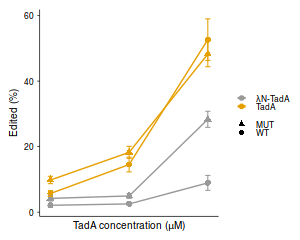

In [43]:
options(repr.plot.width = 2.5, repr.plot.height = 2)

# Create line plot showing concentration dependence for 1+ edits only
mean_loop_editing_per_concentration %>%
  # Calculate 1+ edits (combine 1 and 2+ edits)
  group_by(tada_type, tada_conc, insert_type) %>%
  summarize(mean_1plus = sum(mean), 
            se_1plus = sqrt(sum(se^2)), 
            .groups = "drop") %>%
  # Convert concentration to numeric for line plot
  mutate(tada_conc_numeric = as.numeric(str_extract(tada_conc, "\\d+\\.?\\d*"))) %>%
  ggplot(aes(x = tada_conc_numeric, y = mean_1plus, 
             color = tada_type, 
             shape = insert_type,
             group = interaction(tada_type, insert_type))) +
  geom_point(size = 1.5, stroke = 0.3) +
  geom_line(linewidth = 0.4) +
  geom_errorbar(aes(ymin = mean_1plus - se_1plus, ymax = mean_1plus + se_1plus), 
                width = 0.02, linewidth = 0.3) +
  scale_x_continuous(name = "TadA concentration (μM)", 
                     breaks = c(0.1, 0.5, 2.5),
                     labels = c("0.1", "0.5", "2.5"),
                     trans = "log10") +
  scale_color_manual(values = cbPalette,
                     labels = c("tada_only" = "TadA", "lambdaN" = "λN-TadA"),
                     name = NULL) +
  scale_shape_manual(values = c("wt" = 16, "mut" = 17),
                     labels = c("wt" = "WT", "mut" = "MUT"),
                     name = NULL) +
  labs(y = "Edited (%)") +
  theme_classic() +
  theme(
    legend.position = "right",
    legend.box = "vertical",
    legend.margin = margin(0, 0, 0, 0),
    legend.spacing.y = unit(0.1, "cm"),
    axis.title = element_text(size = 6, color = "black"),
    axis.text = element_text(size = 5, color = "black"),
    legend.text = element_text(size = 5, color = "black"),
    axis.line = element_line(linewidth = 0.2, color = "black"),
    axis.ticks = element_line(linewidth = 0.2, color = "black"),
    axis.ticks.length = unit(0.05, "cm"),
    panel.background = element_rect(fill = "white"),
    plot.background = element_rect(fill = "white"),
    legend.key.size = unit(0.3, "cm"),
    plot.margin = margin(2, 2, 2, 2, "mm")
  ) +
  guides(
    color = guide_legend(override.aes = list(linewidth = 0.6, size = 1.2), 
                        title = NULL, keywidth = 0.4, keyheight = 0.3),
    shape = guide_legend(override.aes = list(linewidth = 0.6, size = 1.2),
                        title = NULL, keywidth = 0.4, keyheight = 0.3)
  )

ggsave("../figures/fig2b_loop_concentration.pdf", width = 2.5, height = 2, units = "in", dpi = 600)